In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import sys
import gc
import numpy as np
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import layers, models, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger, EarlyStopping
import matplotlib.pyplot as plt
from sklearn.utils import shuffle

2026-01-15 13:36:17.550712: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-15 13:36:18.387851: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-15 13:36:18.654669: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
%load_ext autoreload
%autoreload 2

# Pega o diretório atual e sobe um nível ('..')
project_root = os.path.abspath('..')

# Adiciona este diretório ao sys.path se ele ainda não estiver lá
if project_root not in sys.path:
    sys.path.append(project_root)

# --- Seus imports originais ---
import utils.processamento_dados as proc_dados
import utils.metricas_e_visualizacao as met_vil

In [3]:
# --- 2. CONFIGURAÇÕES DE AMBIENTE E CAMINHOS ---
# Configuração básica de GPU (Memory Growth) para evitar alocação total imediata
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

I0000 00:00:1768495074.869934 1542942 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768495074.875224 1542942 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768495074.875269 1542942 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.


In [4]:
# DEFINA SEUS CAMINHOS AQUI:
BASE_DIR = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI"

data_dir_train = f"{BASE_DIR}/ADNI_NORMALIZED/train"
data_dir_val = f"{BASE_DIR}/ADNI_NORMALIZED/validation"
data_dir_test = f"{BASE_DIR}/ADNI_NORMALIZED/test"

data_3t_dir = os.path.join(BASE_DIR, "ADNI_3_4_NORMALIZED")
results_dir = os.path.join(BASE_DIR, "results", "full_fine_tuning_3t_k_fold")
os.makedirs(results_dir, exist_ok=True)

adni_class_names = ['cn', 'ad']

In [6]:
n = len(os.listdir(results_dir))

folder_name = f"test_{str(n+1)}_4_camadas"
results_dir = os.path.join(results_dir, folder_name)
os.makedirs(results_dir, exist_ok=True)
print(f"pasta {folder_name} criada")

pre_results_dir = f"{results_dir}/pre"
os.makedirs(pre_results_dir, exist_ok=True)
post_results_dir = f"{results_dir}/post"
os.makedirs(post_results_dir, exist_ok=True)

pasta test_3_4_camadas criada


In [7]:
# Nome do modelo pré-treinado (Treinado no dataset 1.5T)
# pretrained_model_path = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/results_fit_15_predict_3/test_1/binary_classifier_noise_200_epochs_batch_15_2_classes.keras"

def create_model_3d(input_shape, n_classes):
    # Entrada
    inputs = Input(shape=input_shape)  # (D, H, W, C)

    # === Camada 1 ===
    x = layers.Conv3D(4, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(inputs)
    x = layers.Conv3D(4, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(4, 4, 4), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # === Camada 2 ===
    x = layers.Conv3D(8, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    # x = layers.Conv3D(8, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # === Camada 3 ===
    x = layers.Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    # x = layers.Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # === Classificador ===
    x = layers.Flatten()(x)

    x = layers.Dense(16, kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    # === Adaptação da Saída ===
    if n_classes == 2:
        # Binário: 1 neurônio com Sigmoid (para funcionar com binary_crossentropy)
        outputs = layers.Dense(1, activation='sigmoid')(x)
    else:
        # Multiclasse: N neurônios com Softmax
        outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="Small_Leaky_3D_Model")
    
    return model

## Pré-treinamento

In [8]:
# --- FLUXO PRINCIPAL (Carregamento Simples sem Augmentation) ---

# 2. Carregar Dados diretamente de cada pasta
print(f"Carregando dados de Treino de: {data_dir_train} ...")
X_train_final, y_train_final = proc_dados.load_nifti_data(data_dir_train)

print(f"Carregando dados de Validação de: {data_dir_val} ...")
X_val, y_val = proc_dados.load_nifti_data(data_dir_val)

# Verificação básica
if len(X_train_final) == 0:
    print("ERRO: Nenhum dado de treino encontrado. Verifique se a pasta 'train' existe e contém imagens.")
else:
    
    X_train_final, y_train_final = shuffle(X_train_final, y_train_final, random_state=42)

    print(f"\n--- Resultado Final (Sem Augmentation) ---")
    print(f"Treino:     {X_train_final.shape}")
    print(f"Validação:  {X_val.shape}")

Carregando dados de Treino de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/train ...
Carregando dados de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/train


Lendo ad: 100%|██████████| 534/534 [01:02<00:00,  8.48it/s]


Dados carregados. Shape: (1064, 156, 195, 160, 1)
Carregando dados de Validação de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/validation ...
Carregando dados de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/validation


Lendo ad: 100%|██████████| 152/152 [00:20<00:00,  7.32it/s]


Dados carregados. Shape: (289, 156, 195, 160, 1)

--- Resultado Final (Sem Augmentation) ---
Treino:     (1064, 156, 195, 160, 1)
Validação:  (289, 156, 195, 160, 1)


In [10]:
# Instancia o novo modelo
model = create_model_3d(input_shape=X_train_final[0].shape, n_classes=2)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='binary_crossentropy', 
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

I0000 00:00:1768496446.734546 1542942 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768496446.734638 1542942 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768496446.734662 1542942 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768496447.242508 1542942 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1768496447.242591 1542942 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

Model: "Small_Leaky_3D_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 156, 195, 160,  │             0 │
│                                 │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 156, 195, 160,  │           112 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 156, 195, 160,  │            16 │
│ (BatchNormalization)            │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 156, 195, 160,  │             0 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d               │ (None, 39, 49, 40, 4)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 39, 49, 40, 4)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 39, 49, 40, 8)  │           872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 39, 49, 40, 8)  │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 39, 49, 40, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_1             │ (None, 13, 17, 14, 8)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 13, 17, 14, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_3 (Conv3D)               │ (None, 13, 17, 14, 16) │         3,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 13, 17, 14, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 13, 17, 14, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_2             │ (None, 5, 6, 5, 16)    │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 6, 5, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        38,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             

 Total params: 43,065 (168.22 KB)

 Trainable params: 42,977 (167.88 KB)

 Non-trainable params: 88 (352.00 B)

In [9]:
batch_size = 8

steps_per_epoch = len(X_train_final) // batch_size
validation_steps = len(X_val) // batch_size

epochs = 150

new_model_name_ker = (f"binary_classifier_noise_{epochs}_epochs_batch_{batch_size}_{2}_classes.keras")

# Parar caso fique {patience} épocas sem melhora
early_stopping = EarlyStopping(
    restore_best_weights=True,
    monitor='val_accuracy',     
    patience=20,                 
    verbose=1
)

# # Defina o nome do arquivo para salvar o melhor modelo
model_checkpoint_callback = ModelCheckpoint(
    filepath=os.path.join(pre_results_dir, new_model_name_ker),    
    monitor='val_accuracy',
    save_best_only=True, 
    mode='max', 
)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1)

log_path = os.path.join(pre_results_dir, 'log_treino_ruido.csv')
csv_log = CSVLogger(log_path, append=False)

In [11]:
# Forçar coleta de lixo para liberar qualquer memória residual antes de começar
gc.collect()

# Ela pega os dados diretamente das suas variáveis globais X_train_final e y_train_final
def train_gen():
    for i in range(len(X_train_final)):
        yield X_train_final[i], y_train_final[i]

def val_gen():
    for i in range(len(X_val)):
        yield X_val[i], y_val[i]

output_signature = (
    tf.TensorSpec(shape=(156, 195, 160, 1), dtype=tf.float16),
    tf.TensorSpec(shape=(), dtype=tf.int16)               
)

# --- Criação dos Datasets ---
print("Criando Dataset de Treino via Generator...")
train_dataset = tf.data.Dataset.from_generator(
    train_gen,
    output_signature=output_signature
)

# Agora aplicamos batch e prefetch
train_dataset = train_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

print("Criando Dataset de Validação via Generator...")
val_dataset = tf.data.Dataset.from_generator(
    val_gen,
    output_signature=output_signature
)
val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

Criando Dataset de Treino via Generator...
Criando Dataset de Validação via Generator...


In [12]:
# 3. Treinamento usando o Dataset
history = model.fit(
    train_dataset,  
    epochs=epochs,
    verbose=1,
    validation_data=val_dataset,
    callbacks=[model_checkpoint_callback, csv_log, early_stopping, reduce_lr]
)

Epoch 1/150


I0000 00:00:1768496775.909618 1546227 service.cc:146] XLA service 0x7f2080807f40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768496775.909667 1546227 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-01-15 14:06:22.895119: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng26{k2=0,k13=2,k14=3,k18=0,k22=0,k23=0} for conv (f32[8,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[8,1,156,195,160]{4,3,2,1,0}, f32[4,1,3,3,3]{4,3,2,1,0}, f32[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-01-15 14:06:23.223273: E external/local_xl

    133/Unknown 45s 151ms/step - accuracy: 0.5573 - auc: 0.5841 - loss: 1.2458

/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
2026-01-15 14:07:05.797062: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %reduce-window.132 = f32[1,39,49,40,4]{4,3,2,1,0} reduce-window(f32[1,156,195,160,4]{4,3,2,1,0} %broadcast.121, f32[] %constant.122), window={size=1x4x4x4x1 stride=1x4x4x4x1 pad=0_0x0_0x0_1x0_0x0_0}, to_apply=%region_1.128, metadata={op_type="AvgPool3D" op_name="Small_Leaky_3D_Model_1/average_pooling3d_1/AvgPool3D"}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has

133/133 ━━━━━━━━━━━━━━━━━━━━ 55s 231ms/step - accuracy: 0.5752 - auc: 0.6124 - loss: 1.1977 - val_accuracy: 0.5260 - val_auc: 0.9114 - val_loss: 1.1031 - learning_rate: 0.0010
Epoch 2/150
133/133 ━━━━━━━━━━━━━━━━━━━━ 26s 197ms/step - accuracy: 0.6288 - auc: 0.6718 - loss: 1.0693 - val_accuracy: 0.5260 - val_auc: 0.9108 - val_loss: 1.4328 - learning_rate: 0.0010
Epoch 3/150
133/133 ━━━━━━━━━━━━━━━━━━━━ 26s 195ms/step - accuracy: 0.6466 - auc: 0.6998 - loss: 0.9790 - val_accuracy: 0.5260 - val_auc: 0.9269 - val_loss: 1.9116 - learning_rate: 0.0010
Epoch 4/150
133/133 ━━━━━━━━━━━━━━━━━━━━ 26s 195ms/step - accuracy: 0.6391 - auc: 0.6935 - loss: 0.9367 - val_accuracy: 0.5260 - val_auc: 0.5000 - val_loss: 3.4363 - learning_rate: 0.0010
Epoch 5/150
133/133 ━━━━━━━━━━━━━━━━━━━━ 25s 188ms/step - accuracy: 0.6711 - auc: 0.7270 - loss: 0.8668 - val_accuracy: 0.5260 - val_auc: 0.9382 - val_loss: 1.4105 - learning_rate: 0.0010
Epoch 6/150
133/133 ━━━━━━━━━━━━━━━━━━━━ 27s 193ms/step - accuracy: 0.67

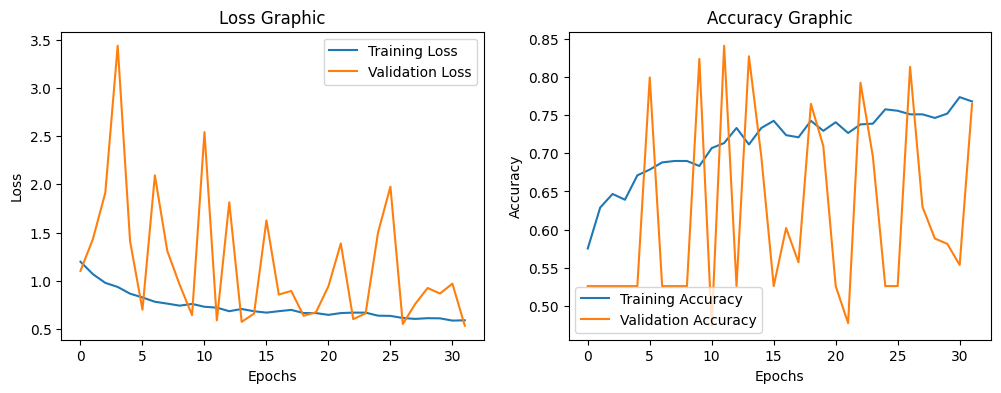

In [13]:
# Plotando o histórico de treinamento após o treinamento
met_vil.plot_training_history_binary(history, f"{pre_results_dir}")

#### Predição validação e teste

              precision    recall  f1-score   support

           0       0.90      0.74      0.82       137
           1       0.80      0.93      0.86       152

    accuracy                           0.84       289
   macro avg       0.85      0.84      0.84       289
weighted avg       0.85      0.84      0.84       289



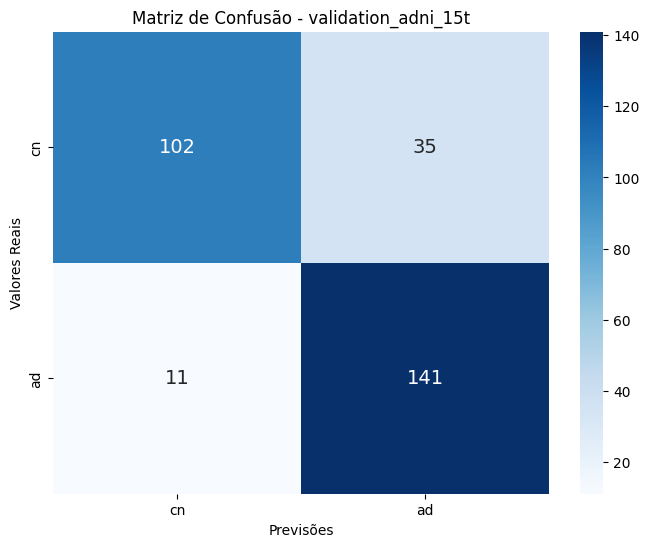

In [14]:
# Realizar predições para dados do conjunto validação
val_pred_labels, val_true_labels, val_pred = met_vil.get_predictions_binary(X_val, y_val, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(val_true_labels, val_pred_labels, pre_results_dir, 'validation_adni_15t')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(val_true_labels, val_pred_labels, pre_results_dir, 'validation_adni_15t', adni_class_names)

Carregando dados de Teste de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/test ...
Carregando dados de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/test


Lendo ad: 100%|██████████| 77/77 [00:11<00:00,  6.77it/s]


Dados carregados. Shape: (150, 156, 195, 160, 1)
Teste:      (150, 156, 195, 160, 1)


2026-01-15 14:21:43.090281: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng26{k2=0,k13=2,k14=3,k18=0,k22=0,k23=0} for conv (f32[6,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[6,1,156,195,160]{4,3,2,1,0}, f32[4,1,3,3,3]{4,3,2,1,0}, f32[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-01-15 14:21:43.108534: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.01833708s
Trying algorithm eng26{k2=0,k13=2,k14=3,k18=0,k22=0,k23=0} for conv (f32[6,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[6,1,156,195,160]{4,3,2,1,0}, f32[4,1,3,3,3]{4,3,2,1,0}, f32[4]{0}), window={size=3x3x3 pad=1_1x1_1

              precision    recall  f1-score   support

           0       0.89      0.55      0.68        73
           1       0.69      0.94      0.79        77

    accuracy                           0.75       150
   macro avg       0.79      0.74      0.73       150
weighted avg       0.78      0.75      0.74       150



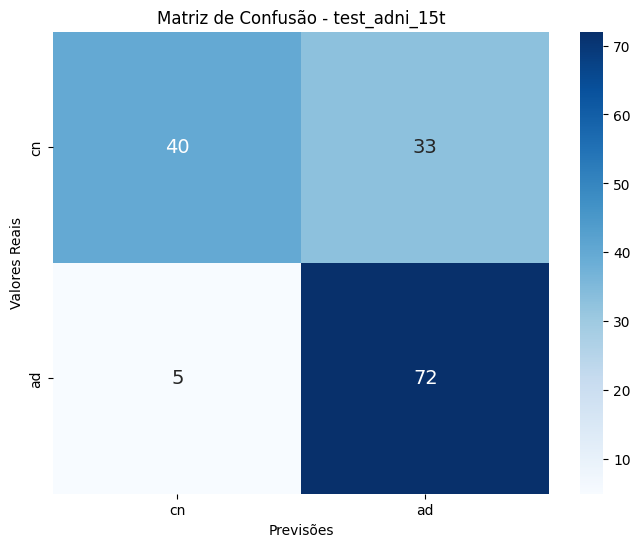

In [15]:
print(f"Carregando dados de Teste de: {data_dir_test} ...")
X_test, y_test = proc_dados.load_nifti_data(data_dir_test)
print(f"Teste:      {X_test.shape}")

# Realizar predições para dados do conjunto validação
test_pred_labels, test_true_labels, test_pred = met_vil.get_predictions_binary(X_test, y_test, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(test_true_labels, test_pred_labels, pre_results_dir, 'test_adni_15t')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(test_true_labels, test_pred_labels, pre_results_dir, 'test_adni_15t', adni_class_names)

#### Predição 3T

In [16]:
del X_train_final, y_train_final, X_val, y_val, X_test, y_test

In [17]:
# === 4. PREPARAÇÃO DOS DADOS 3T (União de todas as pastas) ===
print("--- Carregando e Unificando Dados 3T ---")

dir_3t_train = os.path.join(data_3t_dir, "train")
dir_3t_val = os.path.join(data_3t_dir, "validation")
dir_3t_test = os.path.join(data_3t_dir, "test")

parts_X = []
parts_y = []

# Carrega tudo usando a função do seu módulo local
for d in [dir_3t_train, dir_3t_val, dir_3t_test]:
    print(f"Lendo pasta: {d}")
    try:
        x_part, y_part = proc_dados.load_nifti_data(d)
        if len(x_part) > 0:
            parts_X.append(x_part)
            parts_y.append(y_part)
    except Exception as e:
        print(f"Erro ao ler pasta {d}: {e}")

if len(parts_X) > 0:
    X_3t_all = np.concatenate(parts_X, axis=0)
    y_3t_all = np.concatenate(parts_y, axis=0)
    print(f"Total de dados 3T para K-Fold: {X_3t_all.shape}")
else:
    raise ValueError("Não foram encontrados dados nas pastas 3T.")

--- Carregando e Unificando Dados 3T ---
Lendo pasta: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_3_4_NORMALIZED/train
Carregando dados de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_3_4_NORMALIZED/train


Lendo ad: 100%|██████████| 88/88 [00:08<00:00,  9.82it/s]


Dados carregados. Shape: (699, 156, 195, 160, 1)
Lendo pasta: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_3_4_NORMALIZED/validation
Carregando dados de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_3_4_NORMALIZED/validation


Lendo ad: 100%|██████████| 27/27 [00:02<00:00,  9.90it/s]


Dados carregados. Shape: (202, 156, 195, 160, 1)
Lendo pasta: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_3_4_NORMALIZED/test
Carregando dados de: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_3_4_NORMALIZED/test


Lendo ad: 100%|██████████| 13/13 [00:01<00:00,  9.76it/s]


Dados carregados. Shape: (102, 156, 195, 160, 1)
Total de dados 3T para K-Fold: (1003, 156, 195, 160, 1)


              precision    recall  f1-score   support

           0       0.94      0.72      0.82       875
           1       0.26      0.67      0.38       128

    accuracy                           0.72      1003
   macro avg       0.60      0.70      0.60      1003
weighted avg       0.85      0.72      0.76      1003



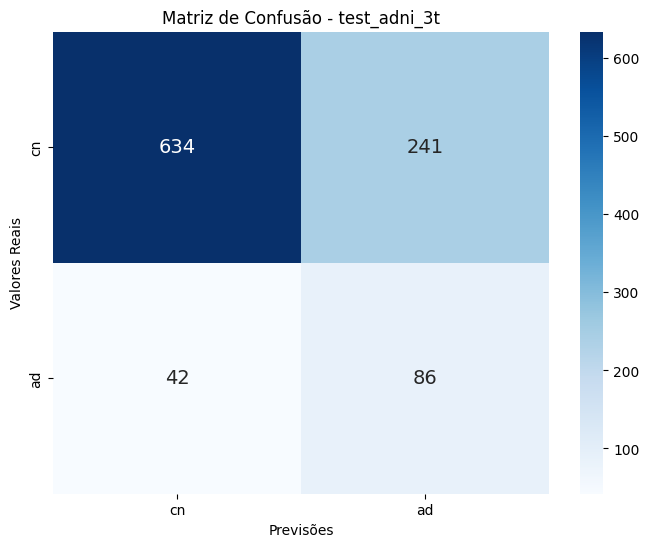

In [18]:
# Realizar predições para dados do conjunto validação
test_pred_labels, test_true_labels, test_pred = met_vil.get_predictions_binary(X_3t_all, y_3t_all, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(test_true_labels, test_pred_labels, pre_results_dir, 'test_adni_3t')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(test_true_labels, test_pred_labels, pre_results_dir, 'test_adni_3t', adni_class_names)

## Fine Tunning

In [19]:
# === 5. CONFIGURAÇÃO DO K-FOLD E MODELO ===
K_FOLDS = 5
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

# Listas para armazenar métricas de cada fold
fold_accuracies = []
fold_aucs = []

all_true_labels = []
all_pred_labels = []

print(f"\n>>> INICIANDO FINE-TUNING (K-FOLD = {K_FOLDS}) <<<")


>>> INICIANDO FINE-TUNING (K-FOLD = 5) <<<


In [20]:
BATCH_SIZE = 8
EPOCHS = 50
K_FOLDS = 5
LEARNING_RATE = 0.001

# Garante que o K-Fold está definido
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

In [ ]:
# Listas globais
fold_accuracies = []
fold_aucs = []
aggregated_true_labels = []
aggregated_pred_labels = []

# ==========================================
# 2. FUNÇÕES AUXILIARES (Augmentation & Generator)
# ==========================================

def augment_and_balance_in_ram(X_full, y_full, indices):
    # 1. Pega labels deste fold para contagem
    y_subset = y_full[indices]
    
    # 2. Identifica classe minoritária e majoritária
    counts = np.bincount(y_subset)
    minority_class = np.argmin(counts)
    majority_class = np.argmax(counts)
    n_minority = counts[minority_class]
    n_majority = counts[majority_class]
    
    print(f"   > Balanceamento: Majoritária ({majority_class}): {n_majority} | Minoritária ({minority_class}): {n_minority}")
    
    # 3. Calcula tamanho final
    total_final = n_majority + (n_minority * 4)
    
    # --- CORREÇÃO AQUI: Detecção Dinâmica de Shape ---
    sample_shape = X_full[0].shape
    
    # Se for (D, H, W), vira (D, H, W, 1). Se já for (D, H, W, C), mantém.
    if len(sample_shape) == 3:
        final_sample_shape = (*sample_shape, 1)
        needs_expansion = True # Indica que precisaremos expandir os originais
    else:
        final_sample_shape = sample_shape
        needs_expansion = False # Já tem canal

    final_shape = (total_final, *final_sample_shape)
    # -----------------------------------------------
    
    print(f"   > Alocando memória para {total_final} amostras (float16). Shape final: {final_shape}")
    
    # 4. Alocação
    try:
        X_aug = np.empty(final_shape, dtype=np.float16) 
        y_aug = np.empty((total_final,), dtype=np.int16)
    except MemoryError:
        print("ERRO FATAL: Memória RAM insuficiente para Augmentation.")
        raise
        
    # 5. Preenchimento e Augmentation
    cursor = 0
    total_indices = len(indices)
    
    for idx, i in enumerate(indices):
        orig = X_full[i] 
        lbl = y_full[i]
        
        # Prepara o original com o shape correto para inserção
        if needs_expansion:
            # (D, H, W) -> (D, H, W, 1)
            orig_ready = np.expand_dims(orig, axis=-1)
        else:
            # Já é (D, H, W, C)
            orig_ready = orig

        if lbl == majority_class:
            # Classe Majoritária: Copia apenas o original
            X_aug[cursor] = orig_ready
            y_aug[cursor] = lbl
            cursor += 1
        else:
            # Classe Minoritária: Original + 3 Augmentations
            
            # 1. Original
            X_aug[cursor] = orig_ready
            y_aug[cursor] = lbl
            cursor += 1
            
            # --- CORREÇÃO DO LOOP: Lógica condicional para Augmentation ---
            # Função auxiliar interna para garantir shape correto vindo do augment
            def ensure_shape(img_aug):
                # Se a função de augment retornou 3D, expande.
                if len(img_aug.shape) == 3:
                    return np.expand_dims(img_aug, axis=-1)
                # Se retornou 4D, verifica se bate com o target
                return img_aug

            # 2. Zoom
            zoom_img = proc_dados.augment_zoom(orig) 
            X_aug[cursor] = ensure_shape(zoom_img)
            y_aug[cursor] = lbl
            cursor += 1
            
            # 3. Shift
            shift_img = proc_dados.augment_shift(orig)
            X_aug[cursor] = ensure_shape(shift_img)
            y_aug[cursor] = lbl
            cursor += 1
            
            # 4. Rotation
            rot_img = proc_dados.augment_rotation(orig)
            X_aug[cursor] = ensure_shape(rot_img)
            y_aug[cursor] = lbl
            cursor += 1
            
        if idx % 100 == 0:
            print(f"    Processando: {idx}/{total_indices}...", end='\r')
            
    print(f"\nDados Augmentados na RAM! Shape: {X_aug.shape}")
    
    # 6. Embaralhar
    shuf_idxs = np.arange(total_final)
    np.random.shuffle(shuf_idxs)
    
    return X_aug[shuf_idxs], y_aug[shuf_idxs]

def numpy_generator(x_data, y_data):
    for i in range(len(x_data)):
        yield x_data[i].astype(np.float32), y_data[i]

# LOOP PRINCIPAL
for fold_idx, (train_index, val_index) in enumerate(skf.split(X_3t_all, y_3t_all)):
    print(f"\n{'='*40}")
    print(f"INICIANDO FOLD {fold_idx+1}/{K_FOLDS} (FINE-TUNING COM AUGMENTATION)")
    print(f"{'='*40}")

    fold_dir = os.path.join(post_results_dir, f"fold_ft_{fold_idx+1}")
    os.makedirs(fold_dir, exist_ok=True)

    # --- A. PREPARAÇÃO DOS DADOS ---
    
    # VALIDAÇÃO: 
    X_val_fold = X_3t_all[val_index]
    if len(X_val_fold.shape) == 3:
        X_val_fold = np.expand_dims(X_val_fold, axis=-1)
    X_val_fold = X_val_fold.astype(np.float32)
    y_val_fold = y_3t_all[val_index]

    # TREINO: 
    # Aplicamos a função de Augmentation na RAM
    print("Gerando Augmentation e Balanceamento na RAM...")
    try:
        X_train_aug, y_train_aug = augment_and_balance_in_ram(X_3t_all, y_3t_all, train_index)
    except MemoryError:
        print("FATAL: Memória insuficiente no augmentation. Parando execução.")
        break
    except Exception as e:
        print(f"Erro no augmentation: {e}")
        break

    # --- B. CONFIGURAR GENERATORS (TF.DATA) ---
    print("Configurando tf.data Generators...")
    
    # Especificações dos tensores
    # Treino é float16 (conforme saído do augment_and_balance)
    train_spec_img = tf.TensorSpec(shape=X_train_aug.shape[1:], dtype=tf.float32) 
    train_spec_lbl = tf.TensorSpec(shape=(), dtype=tf.int32)
    
    # Validação é float32
    val_spec_img = tf.TensorSpec(shape=X_val_fold.shape[1:], dtype=tf.float32)
    val_spec_lbl = tf.TensorSpec(shape=(), dtype=tf.int32)

    # Dataset Treino (Generator converte f16 -> f32 on-the-fly)
    train_dataset = tf.data.Dataset.from_generator(
        lambda: numpy_generator(X_train_aug, y_train_aug),
        output_signature=(train_spec_img, train_spec_lbl)
    )
    # Shuffle buffer e Prefetch
    train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # Dataset Validação
    val_dataset = tf.data.Dataset.from_generator(
        lambda: numpy_generator(X_val_fold, y_val_fold),
        output_signature=(val_spec_img, val_spec_lbl)
    )
    val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # 3. Congela camadas iniciais (Bloco 1)
    print("   Congelando camadas iniciais (0 a 5)...")
    for i in range(13):
        model.layers[i].trainable = False
        print(f"{model.layers[i]} congelada!")

    # 4. Compila
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), 
        loss='binary_crossentropy', 
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    
    # Callbacks
    model_name = f"model_ft_fold_{fold_idx+1}.keras"
    model_save_path = os.path.join(fold_dir, model_name)
    
    callbacks_list = [
        ModelCheckpoint(model_save_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=0),
        EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ]

    # --- D. TREINAMENTO ---
    print("🚀 Iniciando Fine-Tuning...")
    history = model.fit(
        train_dataset,
        epochs=EPOCHS,
        validation_data=val_dataset,
        callbacks=callbacks_list,
        verbose=1
    )
    
    # Salva gráfico histórico
    met_vil.plot_training_history_binary(history, fold_dir)

    # --- E. AVALIAÇÃO E PREDIÇÃO ---
    print("Carregando melhor modelo do fold para avaliação...")
    best_model = models.load_model(model_save_path)
    
    # Avaliação numérica
    loss, acc, auc = best_model.evaluate(val_dataset, verbose=0)
    fold_accuracies.append(acc)
    fold_aucs.append(auc)
    print(f"   Resultado Fold {fold_idx+1}: Acc={acc:.4f}, AUC={auc:.4f}")

    preds_prob = best_model.predict(val_dataset, verbose=0)
    pred_labels = (preds_prob > 0.5).astype(int).flatten()
    true_labels = y_val_fold 
    
    # Garante shapes compatíveis
    limit = min(len(pred_labels), len(true_labels))
    pred_labels = pred_labels[:limit]
    true_labels = true_labels[:limit]

    # Relatórios
    met_vil.get_classification_report(true_labels, pred_labels, fold_dir, f'report_ft_fold_{fold_idx+1}')
    met_vil.plot_confusion_matrix(true_labels, pred_labels, fold_dir, f'conf_matrix_ft_fold_{fold_idx+1}', adni_class_names)

    # Acumula para relatório global
    aggregated_true_labels.extend(true_labels)
    aggregated_pred_labels.extend(pred_labels)

    # --- F. LIMPEZA DE MEMÓRIA ---
    print("🧹 Limpando memória...")
    del X_train_aug, y_train_aug, X_val_fold, y_val_fold
    del train_dataset, val_dataset, best_model, history
    tf.keras.backend.clear_session()
    gc.collect()


INICIANDO FOLD 1/5 (FINE-TUNING COM AUGMENTATION)
Gerando Augmentation e Balanceamento na RAM...
   > Balanceamento: Majoritária (0): 700 | Minoritária (1): 102
   > Alocando memória para 1108 amostras (float16). Shape final: (1108, 156, 195, 160, 1)
    Processando: 800/802...
Dados Augmentados na RAM! Shape: (1108, 156, 195, 160, 1)
Configurando tf.data Generators...
   Congelando camadas iniciais (0 a 5)...
<InputLayer name=input_layer, built=True> congelada!
<Conv3D name=conv3d_1, built=True> congelada!
<BatchNormalization name=batch_normalization, built=True> congelada!
<LeakyReLU name=leaky_re_lu, built=True> congelada!
<AveragePooling3D name=average_pooling3d, built=True> congelada!
<Dropout name=dropout, built=True> congelada!
<Conv3D name=conv3d_2, built=True> congelada!
<BatchNormalization name=batch_normalization_1, built=True> congelada!
<LeakyReLU name=leaky_re_lu_1, built=True> congelada!
<AveragePooling3D name=average_pooling3d_1, built=True> congelada!
<Dropout name=dr

/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
2026-01-15 14:31:57.640622: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 2s:

  %reduce-window.119 = f32[1,39,49,40,4]{4,3,2,1,0} reduce-window(f32[1,156,195,160,4]{4,3,2,1,0} %broadcast.108, f32[] %constant.109), window={size=1x4x4x4x1 stride=1x4x4x4x1 pad=0_0x0_0x0_1x0_0x0_0}, to_apply=%region_1.115, metadata={op_type="AvgPool3D" op_name="Small_Leaky_3D_Model_1/average_pooling3d_1/AvgPool3D"}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has

139/139 ━━━━━━━━━━━━━━━━━━━━ 47s 278ms/step - accuracy: 0.7644 - auc: 0.8261 - loss: 0.6119 - val_accuracy: 0.8756 - val_auc: 0.7459 - val_loss: 0.4273 - learning_rate: 0.0010
Epoch 2/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 27s 190ms/step - accuracy: 0.7608 - auc: 0.8359 - loss: 0.5668 - val_accuracy: 0.7960 - val_auc: 0.7227 - val_loss: 0.5183 - learning_rate: 0.0010
Epoch 3/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 27s 191ms/step - accuracy: 0.7735 - auc: 0.8371 - loss: 0.5657 - val_accuracy: 0.8507 - val_auc: 0.7285 - val_loss: 0.4566 - learning_rate: 0.0010
Epoch 4/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 28s 198ms/step - accuracy: 0.7789 - auc: 0.8443 - loss: 0.5531 - val_accuracy: 0.8060 - val_auc: 0.7391 - val_loss: 0.5229 - learning_rate: 0.0010
Epoch 5/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 26s 189ms/step - accuracy: 0.7987 - auc: 0.8442 - loss: 0.5571 - val_accuracy: 0.8259 - val_auc: 0.7446 - val_loss: 0.4701 - learning_rate: 0.0010
Epoch 6/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 26s 184ms/step - accuracy: 0.7717 - 

In [ ]:
# ==========================================
# 4. RESULTADOS FINAIS AGREGADOS
# ==========================================
print("\n=== FINE-TUNING FINALIZADO ===")
print(f"Acurácia Média: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})")
print(f"AUC Média: {np.mean(fold_aucs):.4f} (+/- {np.std(fold_aucs):.4f})")

# Gera Matriz Global
final_true = np.array(all_true_labels)
final_pred = np.array(all_pred_labels)

if len(final_true) > 0:
    met_vil.plot_confusion_matrix(
        final_true, 
        final_pred, 
        results_dir, 
        'FINAL_AGGREGATED_CONFUSION_MATRIX_FT', 
        ['cn', 'ad']
    )
    
    met_vil.get_classification_report(
        final_true, 
        final_pred, 
        results_dir, 
        'FINAL_AGGREGATED_REPORT_FT'
    )